# Shapiro Demand/Supply Decomposition for Supercore PCE Inflation

This notebook adapts Adam Shapiro's SF Fed demand/supply inflation
decomposition to the non-housing services, or "supercore", line-item set in
`Demand_Supply Decomp/supercore_lines.xlsx`.

The baseline mirrors Shapiro's Stata settings as closely as possible:

- monthly item-level bivariate VARs in quantity and price levels;
- 12 monthly lags;
- 120-month rolling estimation window;
- no residual smoothing;
- no ambiguous threshold (`THRESH1 = 0.0`);
- demand if price and quantity residuals have the same sign;
- supply if price and quantity residuals have opposite signs;
- lagged nominal expenditure shares for inflation contributions.

For this first pass, `START_YEAR = 2010`. With Shapiro's 120-month rolling
window, the first classified monthly observations begin around January 2020 and
the first year-over-year decomposition begins around December 2020. To use the
longer sample later, change `START_YEAR` and rerun.


## Interpretation Guide

The intuition is simple, but the implementation is column-heavy because the
notebook keeps Shapiro's diagnostic buckets.

For each PCE line item and each month, the notebook asks: after controlling for
that item's own recent price and quantity history, did price and quantity move
in the same unexpected direction or in opposite unexpected directions?

- **Demand-driven:** unexpected price and quantity movements have the same sign.
  A positive demand shock pushes both price and quantity up; a negative demand
  shock pushes both down.
- **Supply-driven:** unexpected price and quantity movements have opposite signs.
  A negative supply shock pushes price up and quantity down; a positive supply
  shock pushes price down and quantity up.
- **Ambiguous:** the residual signs are too small or unclear to classify, if an
  ambiguous threshold is used.

The most important output columns are:

| Column | How to read it |
|---|---|
| `total_contr_y` | Reconstructed raw year-over-year supercore inflation from the selected line items |
| `dem_contr_y` | Demand-driven contribution to YoY inflation, in percentage points |
| `sup_contr_y` | Supply-driven contribution to YoY inflation, in percentage points |
| `amb_contr_y` | Ambiguous contribution to YoY inflation, in percentage points |
| `stacked_total_y` | Demand + supply + ambiguous after Shapiro-style separate bucket compounding |
| `total_contr_m` | Reconstructed month-over-month supercore inflation contribution, in decimal form |
| `dem_contr_m`, `sup_contr_m` | Monthly demand/supply contributions, in decimal form |

For monthly columns, multiply by 100 to read them as percentage points. For
example, `0.0038` means roughly `0.38%` month over month.


## 1. Settings


In [15]:
from __future__ import annotations

from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import math
import re
import time
import warnings

import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "Demand_Supply Decomp"
CACHE = ROOT / "cache"
OUT = ROOT / "output" / "shapiro_supercore_decomp"
FIG = OUT / "figures"
CACHE.mkdir(exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

SUPERCORE_LINES_PATH = ROOT / "supercore_lines.xlsx"

# Start with 2010 as requested. With the Shapiro 120-month window, classified
# events begin around 2020. Later, set this to 1959 or 1969 for a longer run.
START_YEAR = 1969
END_YEAR = 2026

# BEA NIPA underlying detail tables:
# U20403: real PCE / quantity indexes by product
# U20404: PCE price indexes by product
# U20405: current-dollar PCE by product
BEA_DATASET = "NIUnderlyingDetail"
BEA_FREQUENCY = "M"
QUANTITY_TABLE = "U20403"
PRICE_TABLE = "U20404"
SPEND_TABLE = "U20405"

# Shapiro baseline settings.
# The 120-month window is important: each month's classification is based only
# on information available from the prior ten years plus the event month. This
# follows the rolling-window design in Shapiro's Stata code and lets the
# price/quantity relationship evolve over time.
VAR_LAGS = 12
ROLLING_WINDOW = 120

# CUMUL = 1 means the regressions use lags 1 through 12. Shapiro's robustness
# checks also consider cumulative residual horizons, but the published baseline
# uses 1.
CUMUL = 1

# THRESH1 governs the "ambiguous" bucket.
# - 0.00 is Shapiro's no-ambiguous baseline: every finite residual pair is
#   classified as demand or supply based on sign.
# - 0.10 is a common robustness setting in Shapiro's paper: small residuals are
#   treated as too weak to interpret, so the ambiguous bucket becomes active.
THRESH1 = 0.125

# THRESH2 and THRESH3 do not change demand vs supply totals. They split
# classified observations into "possibly", "likely", and "very likely" buckets.
# These buckets are useful diagnostics, but the headline contribution is the sum
# of all three confidence buckets.
THRESH2 = 0.15
THRESH3 = 0.30

# Shapiro flips "less:" foreign-spending lines before computing weights.
# In this supercore workbook, line 338 is "Less: Expenditures in the United
# States by nonresidents".
NEGATIVE_SPEND_LINES = {357, 361, 362, 363, 364, 365, 366, 367, 368}

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=RuntimeWarning)

try:
    display
except NameError:
    display = print


## 2. API and BEA Data Helpers


In [9]:
def read_api_keys(path=ROOT / "API Keys.txt"):
    # Read local API keys without printing them. The BEA call only needs the
    # `BEA:` line in API Keys.txt. The notebook first looks for cached tables
    # and only calls BEA when a needed cache is missing.
    api = {}
    if not path.exists():
        return api
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or ":" not in stripped:
            continue
        key, value = stripped.split(":", 1)
        key = key.strip().upper()
        value = value.strip().strip('"').strip("'")
        if key and value:
            api[key] = value
    return api

API = read_api_keys()

def parse_bea_date(time_period, frequency=BEA_FREQUENCY):
    tp = str(time_period)
    if frequency == "M":
        if "M" in tp:
            year, month = tp.split("M", 1)
            return pd.Timestamp(year=int(year), month=int(month), day=1)
        return pd.Timestamp(year=int(tp[:4]), month=int(tp[5:]), day=1)
    if frequency == "Q":
        if "Q" in tp:
            year, quarter = tp.split("Q", 1)
            return pd.Timestamp(year=int(year), month=3 * int(quarter) - 2, day=1)
        quarter = int(tp[-1])
        return pd.Timestamp(year=int(tp[:4]), month=3 * quarter - 2, day=1)
    raise ValueError(f"Unsupported BEA frequency: {frequency}")

def as_float(value):
    text = str(value).replace(",", "").strip()
    if text in {"", ".", "-", "NA", "(NA)", "nan", "None"}:
        return np.nan
    return float(text)

def normalize_bea_rows(rows, frequency=BEA_FREQUENCY):
    # Convert BEA API JSON rows into a standard long table. The rest of the
    # notebook expects one row per BEA line/date with these columns: line,
    # description, date, and value.
    out = []
    for d in rows:
        line = d.get("LineNumber", d.get("line", d.get("Line")))
        desc = d.get("LineDescription", d.get("desc", d.get("Description", "")))
        value = d.get("DataValue", d.get("value"))
        if line is None or value is None:
            continue
        out.append(
            {
                "line": int(line),
                "desc": str(desc),
                "date": parse_bea_date(d.get("TimePeriod", d.get("date")), frequency),
                "value": as_float(value),
            }
        )
    return pd.DataFrame(out, columns=["line", "desc", "date", "value"])

def exact_cache_path(table, start_year=START_YEAR, end_year=END_YEAR):
    return CACHE / f"bea_{BEA_DATASET}_{table}_{BEA_FREQUENCY}_{start_year}_{end_year}.csv"

def local_csv_candidates(table):
    patterns = [
        f"bea_{BEA_DATASET}_{table}_{BEA_FREQUENCY}_*.csv",
        f"bea_NIPA_{table}_{BEA_FREQUENCY}_*.csv",
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(sorted(CACHE.glob(pattern)))
    return candidates

def read_cached_bea_table(table, start_year=START_YEAR, end_year=END_YEAR):
    # Find an existing BEA cache and trim it to the requested year range. This
    # lets the notebook reuse the broader caches already in the project instead
    # of refetching the same data every time.
    start = pd.Timestamp(start_year, 1, 1)
    end = pd.Timestamp(end_year, 12, 31)
    exact = exact_cache_path(table, start_year, end_year)
    candidates = [exact] if exact.exists() else []
    candidates += [p for p in local_csv_candidates(table) if p not in candidates]
    for path in candidates:
        try:
            df = pd.read_csv(path, parse_dates=["date"])
        except Exception:
            continue
        needed = {"line", "desc", "date", "value"}
        if not needed.issubset(df.columns):
            continue
        df = df[["line", "desc", "date", "value"]].copy()
        df = df[(df["date"] >= start) & (df["date"] <= end)].copy()
        if not df.empty:
            return df
    return None

def fetch_bea_table(table, start_year=START_YEAR, end_year=END_YEAR, retries=4):
    # Fetch one BEA table and return it in the same format as the cache. BEA
    # sometimes rate-limits repeated calls, so the helper waits and retries
    # before failing. Once fetched, the table is saved as CSV for future runs.
    if "BEA" not in API:
        raise RuntimeError("BEA API key not found in API Keys.txt")
    years = ",".join(str(y) for y in range(start_year, end_year + 1))
    params = {
        "UserID": API["BEA"],
        "method": "GetData",
        "DataSetName": BEA_DATASET,
        "TableName": table,
        "Frequency": BEA_FREQUENCY,
        "Year": years,
        "ResultFormat": "JSON",
    }
    url = "https://apps.bea.gov/api/data/?" + urlencode(params)
    last_error = None
    for attempt in range(retries):
        try:
            with urlopen(url, timeout=180) as f:
                raw = json.loads(f.read().decode("utf-8"))
            results = raw.get("BEAAPI", {}).get("Results", {})
            if "Error" in results:
                err = results["Error"]
                raise RuntimeError(f"BEA API error {err.get('APIErrorCode')}: {err.get('APIErrorDescription')}")
            return normalize_bea_rows(results.get("Data", []), BEA_FREQUENCY)
        except Exception as exc:
            last_error = exc
            message = str(exc)
            if "429" not in message and "Too Many Requests" not in message:
                if attempt == retries - 1:
                    break
            time.sleep(20 * (attempt + 1))
    raise RuntimeError(f"Could not fetch BEA table {table}: {last_error}")

def bea_table(table, start_year=START_YEAR, end_year=END_YEAR, refresh=False):
    # Load a BEA table from cache or API.
    cached = None if refresh else read_cached_bea_table(table, start_year, end_year)
    if cached is not None:
        return cached.sort_values(["line", "date"]).reset_index(drop=True)
    df = fetch_bea_table(table, start_year, end_year)
    path = exact_cache_path(table, start_year, end_year)
    df.to_csv(path, index=False)
    return df.sort_values(["line", "date"]).reset_index(drop=True)

def wide_by_line(df, lines):
    sub = df[df["line"].isin(lines)].copy()
    wide = sub.pivot_table(index="date", columns="line", values="value", aggfunc="first").sort_index()
    return wide.reindex(columns=lines)


## 3. Supercore Line Items


In [11]:
supercore_lines = pd.read_excel(SUPERCORE_LINES_PATH)
supercore_lines.columns = [str(c).strip().lower() for c in supercore_lines.columns]
if "line" not in supercore_lines.columns:
    raise ValueError("supercore_lines.xlsx must contain a Line column")
item_col = "item" if "item" in supercore_lines.columns else supercore_lines.columns[-1]

supercore_lines = supercore_lines.rename(columns={item_col: "item"})
supercore_lines["line"] = supercore_lines["line"].astype(int)
supercore_lines = supercore_lines[["line", "item"]].drop_duplicates().sort_values("line").reset_index(drop=True)
SUPERCORE_LINES = supercore_lines["line"].tolist()

print(f"Loaded {len(SUPERCORE_LINES)} supercore line items.")
display(supercore_lines.head(12))


Loaded 77 supercore line items.


,line,item
0,166,Water supply a...
1,174,Physician serv...
2,175,Dental service...
3,176,Paramedical se...
4,183,Hospitals (51)
5,187,Nursing homes ...
6,192,Motor vehicle ...
7,193,Other motor ve...
8,200,Ground transpo...
9,207,Air transporta...


The line-item workbook is the only place you need to edit the supercore
universe. The decomposition logic does not depend on the specific line list.

Two practical checks matter when you change it:

1. Each selected line should exist in all three BEA tables: quantity
   (`U20403`), price (`U20404`), and nominal spending (`U20405`).
2. Avoid double-counting parent and child lines together unless that overlap is
   intentional. The cleanest decomposition uses non-overlapping detailed lines.


## 4. Load BEA Tables


In [17]:
price_long = bea_table(PRICE_TABLE, refresh=True)
quantity_long = bea_table(QUANTITY_TABLE, refresh=True)
spend_long = bea_table(SPEND_TABLE, refresh=True)

prices = wide_by_line(price_long, SUPERCORE_LINES)
quantities = wide_by_line(quantity_long, SUPERCORE_LINES)
spending = wide_by_line(spend_long, SUPERCORE_LINES)

common_dates = prices.index.intersection(quantities.index).intersection(spending.index)
prices = prices.loc[common_dates]
quantities = quantities.loc[common_dates]
spending = spending.loc[common_dates]

spending_adjusted = spending.copy()
for line in NEGATIVE_SPEND_LINES.intersection(spending_adjusted.columns):
    # Shapiro flips spending for subtraction lines before computing expenditure
    # weights. Price and quantity indexes are left as published.
    spending_adjusted[line] = -spending_adjusted[line]

line_desc = (
    price_long[price_long["line"].isin(SUPERCORE_LINES)][["line", "desc"]]
    .drop_duplicates("line")
    .set_index("line")["desc"]
)

coverage = pd.DataFrame(
    {
        "price_nonmissing": prices.notna().sum(),
        "quantity_nonmissing": quantities.notna().sum(),
        "spending_nonmissing": spending.notna().sum(),
        "description": pd.Series(line_desc),
    }
).reindex(SUPERCORE_LINES)

print("BEA sample:", common_dates.min().date(), "to", common_dates.max().date())
print("Negative-spending lines:", sorted(NEGATIVE_SPEND_LINES.intersection(SUPERCORE_LINES)))
display(coverage.head(12))


BEA sample: 2010-01-01 to 2026-04-01
Negative-spending lines: [357, 361, 362, 363, 364, 365, 366, 367, 368]


,price_nonmissing,quantity_nonmissing,spending_nonmissing,description
line,,,,
166,196,196,196,Water supply and sanitation (25)
174,196,196,196,Physician services (44)
175,196,196,196,Dental services (45)
176,196,196,196,Paramedical services (46)
183,196,196,196,Hospitals (51)
187,196,196,196,Nursing homes (52)
192,196,196,196,Motor vehicle maintenance and repair (60)
193,196,196,196,Other motor vehicle services (61)
200,196,196,196,Ground transportation (63)


## 5. Shapiro Rolling VAR Classifier


In [18]:
def regression_design(q_log, p_log, row_index, lags=VAR_LAGS, cumul=CUMUL):
    # Build one VAR row: constant, lagged quantity log levels, and lagged price
    # log levels. Shapiro estimates two reduced-form equations for each item:
    # quantity on lagged quantity and price, and price on lagged quantity and
    # price. The unexpected movements are the residuals from those equations.
    lag_range = range(cumul, cumul + lags)
    vals = [1.0]
    for lag in lag_range:
        vals.append(q_log[row_index - lag])
    for lag in lag_range:
        vals.append(p_log[row_index - lag])
    vals = np.asarray(vals, dtype=float)
    if not np.isfinite(vals).all():
        return None
    return vals

def residual_tstat_at_event(q_log, p_log, dates, event_index, which, window=ROLLING_WINDOW, lags=VAR_LAGS, cumul=CUMUL, 
                            exclude_resid_start = pd.Timestamp(2020, 3, 1), 
                            exclude_resid_end = pd.Timestamp(2023, 12, 31)):
    # Return the event-month residual scaled by the rolling-window residual
    # volatility. This mirrors the Stata code's `predict ..., resid`, followed
    # by residual / residual standard deviation. The sign tells us the direction
    # of the surprise; the magnitude tells us how strong the surprise is
    # relative to that item's recent residual volatility.
    start = max(0, event_index - window)
    x_rows = []
    y_vals = []
    row_indices = []


    event_x = None
    event_y = None
    y_source = q_log if which == "quantity" else p_log

    for row in range(start, event_index + 1):
        if row - (cumul + lags - 1) < 0:
            continue
        x = regression_design(q_log, p_log, row, lags=lags, cumul=cumul)
        y = y_source[row]
        if x is None or not np.isfinite(y):
            continue
        x_rows.append(x)
        y_vals.append(y)
        row_indices.append(row)

        if row == event_index:
            event_x = x
            event_y = y

    if event_x is None or len(y_vals) <= (1 + 2 * lags):
        return np.nan

    X = np.vstack(x_rows)
    y = np.asarray(y_vals, dtype=float)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta

    resid_dates = pd.DatetimeIndex(dates).take(row_indices)

    keep_for_threshold = ~((resid_dates >= exclude_resid_start) & (resid_dates <= exclude_resid_end))
    sd_sample = resid[keep_for_threshold]
    sd = sd_sample.std(ddof=1)

    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float((event_y - event_x @ beta) / sd)  ##return t start

def classify_tstats(tq, tp, thresh1=THRESH1, thresh2=THRESH2, thresh3=THRESH3):
    # Classify a quantity residual and price residual into Shapiro buckets.
    # Same signs imply demand. Opposite signs imply supply.
    #
    # The confidence buckets are based on residual size:
    # - HH: both residuals exceed 0.30 standard deviations in absolute value.
    # - H: both exceed 0.15 standard deviations, but not HH.
    # - L: both exceed THRESH1, but not H or HH.
    #
    # With THRESH1 = 0.0, L captures almost every finite residual pair not
    # already in H/HH. With THRESH1 = 0.10, small residual pairs become
    # ambiguous.
    if not (np.isfinite(tq) and np.isfinite(tp)):
        return {
            "class": "ambiguous",
            "demand": False,
            "supply": False,
            "ambiguous": True,
            "demand_HH": False,
            "demand_H": False,
            "demand_L": False,
            "supply_HH": False,
            "supply_H": False,
            "supply_L": False,
            "demand_positive": False,
            "demand_negative": False,
            "supply_positive": False,
            "supply_negative": False,
        }

    same_hh = ((tq < -thresh3) and (tp < -thresh3)) or ((tq > thresh3) and (tp > thresh3))
    same_h = (((tq < -thresh2) and (tp < -thresh2)) or ((tq > thresh2) and (tp > thresh2))) and not same_hh
    same_l = (((tq < -thresh1) and (tp < -thresh1)) or ((tq > thresh1) and (tp > thresh1))) and not same_h and not same_hh
    demand = same_hh or same_h or same_l

    opp_hh = ((tq < -thresh3) and (tp > thresh3)) or ((tq > thresh3) and (tp < -thresh3))
    opp_h = (((tq < -thresh2) and (tp > thresh2)) or ((tq > thresh2) and (tp < -thresh2))) and not opp_hh
    opp_l = (((tq < -thresh1) and (tp > thresh1)) or ((tq > thresh1) and (tp < -thresh1))) and not opp_h and not opp_hh
    supply = opp_hh or opp_h or opp_l
    ambiguous = not (demand or supply)

    return {
        "class": "demand" if demand else ("supply" if supply else "ambiguous"),
        "demand": demand,
        "supply": supply,
        "ambiguous": ambiguous,
        "demand_HH": same_hh,
        "demand_H": same_h,
        "demand_L": same_l,
        "supply_HH": opp_hh,
        "supply_H": opp_h,
        "supply_L": opp_l,
        "demand_positive": demand and (tp > 0),
        "demand_negative": demand and (tp <= 0),
        "supply_positive": supply and (tp < 0),
        "supply_negative": supply and (tp >= 0),
    }


## 6. Compute Monthly and Year-over-Year Contributions


In [19]:
price_m = prices.pct_change()
p_log = np.log(prices)
q_log = np.log(quantities)

# Monthly item contribution = lagged nominal expenditure share * monthly item
# price change. This is the same approximation Shapiro uses: it is not exactly
# the BEA chain-price formula, but it closely tracks the official aggregate.
supercore_spending = spending_adjusted.sum(axis=1, min_count=1)
weights = spending_adjusted.shift(1).div(supercore_spending.shift(1), axis=0)
line_contrib_m = weights * price_m

dates = prices.index
monthly_rows = []
line_rows = []

for event_index, event_date in enumerate(dates):
    if event_index < ROLLING_WINDOW:
        continue

    # These monthly contribution buckets are stored in decimal form. For
    # example, 0.0025 is 0.25 percentage point month over month.
    row = {
        "date": event_date,
        "demHH_contr_m": 0.0,
        "demH_contr_m": 0.0,
        "demL_contr_m": 0.0,
        "supHH_contr_m": 0.0,
        "supH_contr_m": 0.0,
        "supL_contr_m": 0.0,
        "amb_contr_m": 0.0,
        "demP_contr_m": 0.0,
        "demN_contr_m": 0.0,
        "supP_contr_m": 0.0,
        "supN_contr_m": 0.0,
        "total_contr_m": 0.0,
        "classified_weight": 0.0,
        "demand_weight": 0.0,
        "supply_weight": 0.0,
        "ambiguous_weight": 0.0,
        "n_demand": 0,
        "n_supply": 0,
        "n_ambiguous": 0,
    }

    for line in SUPERCORE_LINES:
        q_arr = q_log[line].to_numpy(dtype=float)
        p_arr = p_log[line].to_numpy(dtype=float)
        tq = residual_tstat_at_event(q_arr, p_arr, dates, event_index, "quantity")
        tp = residual_tstat_at_event(q_arr, p_arr, dates, event_index, "price")
        flags = classify_tstats(tq, tp)

        # Assign the item's inflation contribution to exactly one headline
        # bucket: demand, supply, or ambiguous. The HH/H/L split is diagnostic;
        # the headline demand contribution is their sum.
        contribution = line_contrib_m.at[event_date, line] if line in line_contrib_m.columns else np.nan
        weight = weights.at[event_date, line] if line in weights.columns else np.nan
        if not np.isfinite(contribution):
            contribution = 0.0
        if not np.isfinite(weight):
            weight = 0.0

        row["total_contr_m"] += contribution
        row["classified_weight"] += weight

        if flags["demand_HH"]:
            row["demHH_contr_m"] += contribution
        elif flags["demand_H"]:
            row["demH_contr_m"] += contribution
        elif flags["demand_L"]:
            row["demL_contr_m"] += contribution
        elif flags["supply_HH"]:
            row["supHH_contr_m"] += contribution
        elif flags["supply_H"]:
            row["supH_contr_m"] += contribution
        elif flags["supply_L"]:
            row["supL_contr_m"] += contribution
        else:
            row["amb_contr_m"] += contribution

        if flags["demand_positive"]:
            row["demP_contr_m"] += contribution
        if flags["demand_negative"]:
            row["demN_contr_m"] += contribution
        if flags["supply_positive"]:
            row["supP_contr_m"] += contribution
        if flags["supply_negative"]:
            row["supN_contr_m"] += contribution

        if flags["demand"]:
            row["demand_weight"] += weight
            row["n_demand"] += 1
        elif flags["supply"]:
            row["supply_weight"] += weight
            row["n_supply"] += 1
        else:
            row["ambiguous_weight"] += weight
            row["n_ambiguous"] += 1

        line_rows.append(
            {
                "date": event_date,
                "line": line,
                "item": supercore_lines.set_index("line").at[line, "item"],
                "t_quantity": tq,
                "t_price": tp,
                "classification": flags["class"],
                "monthly_contribution": contribution,
                "lagged_weight": weight,
            }
        )

    monthly_rows.append(row)

monthly = pd.DataFrame(monthly_rows).set_index("date").sort_index()
line_classifications = pd.DataFrame(line_rows).sort_values(["date", "line"]).reset_index(drop=True)

monthly["dem_contr_m"] = monthly["demHH_contr_m"] + monthly["demH_contr_m"] + monthly["demL_contr_m"]
monthly["sup_contr_m"] = monthly["supHH_contr_m"] + monthly["supH_contr_m"] + monthly["supL_contr_m"]

def rolling_compound(series, periods=12):
    # Compound monthly contribution rates into a 12-month contribution.
    return (1.0 + series).rolling(periods).apply(np.prod, raw=True) - 1.0

decomp = monthly.copy()
for col in [
    "demHH_contr_m",
    "demH_contr_m",
    "demL_contr_m",
    "supHH_contr_m",
    "supH_contr_m",
    "supL_contr_m",
    "amb_contr_m",
    "demP_contr_m",
    "demN_contr_m",
    "supP_contr_m",
    "supN_contr_m",
    "dem_contr_m",
    "sup_contr_m",
    "total_contr_m",
]:
    decomp[col.replace("_m", "_y")] = 100.0 * rolling_compound(decomp[col])

# Match the Stata aggregation for total demand/supply YoY: compound the
# confidence buckets first, then add them.
decomp["dem_contr_y"] = decomp["demHH_contr_y"] + decomp["demH_contr_y"] + decomp["demL_contr_y"]
decomp["sup_contr_y"] = decomp["supHH_contr_y"] + decomp["supH_contr_y"] + decomp["supL_contr_y"]
decomp["stacked_total_y"] = decomp["dem_contr_y"] + decomp["sup_contr_y"] + decomp["amb_contr_y"]

monthly_out = OUT / "supercore_shapiro_monthly_contributions.csv"
yoy_out = OUT / "supercore_shapiro_yoy_decomposition.csv"
line_out = OUT / "supercore_shapiro_line_classifications.csv"

monthly.to_csv(monthly_out)
decomp.to_csv(yoy_out)
line_classifications.to_csv(line_out, index=False)

print("Monthly classified sample:", monthly.index.min().date(), "to", monthly.index.max().date())
print("First YoY observation:", decomp["stacked_total_y"].dropna().index.min().date())
print("Saved:", monthly_out)
print("Saved:", yoy_out)
print("Saved:", line_out)

display(
    decomp[["dem_contr_y", "sup_contr_y", "amb_contr_y", "stacked_total_y", "total_contr_y"]]
    .dropna()
    .tail(8)
    .round(3)
)


Monthly classified sample: 2020-01-01 to 2026-04-01
First YoY observation: 2020-12-01
Saved: C:\Users\abour\OneDrive\Inflation Dynamics\Wage Growth Paper\Demand_Supply Decomp\output\shapiro_supercore_decomp\supercore_shapiro_monthly_contributions.csv
Saved: C:\Users\abour\OneDrive\Inflation Dynamics\Wage Growth Paper\Demand_Supply Decomp\output\shapiro_supercore_decomp\supercore_shapiro_yoy_decomposition.csv
Saved: C:\Users\abour\OneDrive\Inflation Dynamics\Wage Growth Paper\Demand_Supply Decomp\output\shapiro_supercore_decomp\supercore_shapiro_line_classifications.csv


,dem_contr_y,sup_contr_y,amb_contr_y,stacked_total_y,total_contr_y
date,,,,,
2025-09-01,1.426,1.264,0.586,3.276,3.313
2025-10-01,1.345,1.163,0.738,3.247,3.283
2025-11-01,1.310,1.247,0.746,3.302,3.340
2025-12-01,1.212,1.241,0.826,3.279,3.317
2026-01-01,1.418,1.351,0.773,3.542,3.586
2026-02-01,1.185,1.340,0.781,3.306,3.345
2026-03-01,1.238,1.437,0.833,3.508,3.552
2026-04-01,1.301,1.422,0.885,3.607,3.654


### Why There Are So Many Columns

The wide output preserves intermediate Shapiro diagnostics. Most readers only
need the headline columns:

- `total_contr_y`: reconstructed YoY supercore inflation.
- `dem_contr_y`: demand-driven YoY contribution.
- `sup_contr_y`: supply-driven YoY contribution.
- `amb_contr_y`: ambiguous YoY contribution.
- `stacked_total_y`: demand + supply + ambiguous, after separate bucket
  compounding.

The `HH`, `H`, and `L` columns are confidence buckets:

- `HH`: very likely demand/supply.
- `H`: likely demand/supply.
- `L`: possible demand/supply.

For example, `dem_contr_y = demHH_contr_y + demH_contr_y + demL_contr_y`.

The `P` and `N` columns split positive and negative price surprises. They are
helpful for diagnostics but are not needed for the main chart.


## 7. Chart


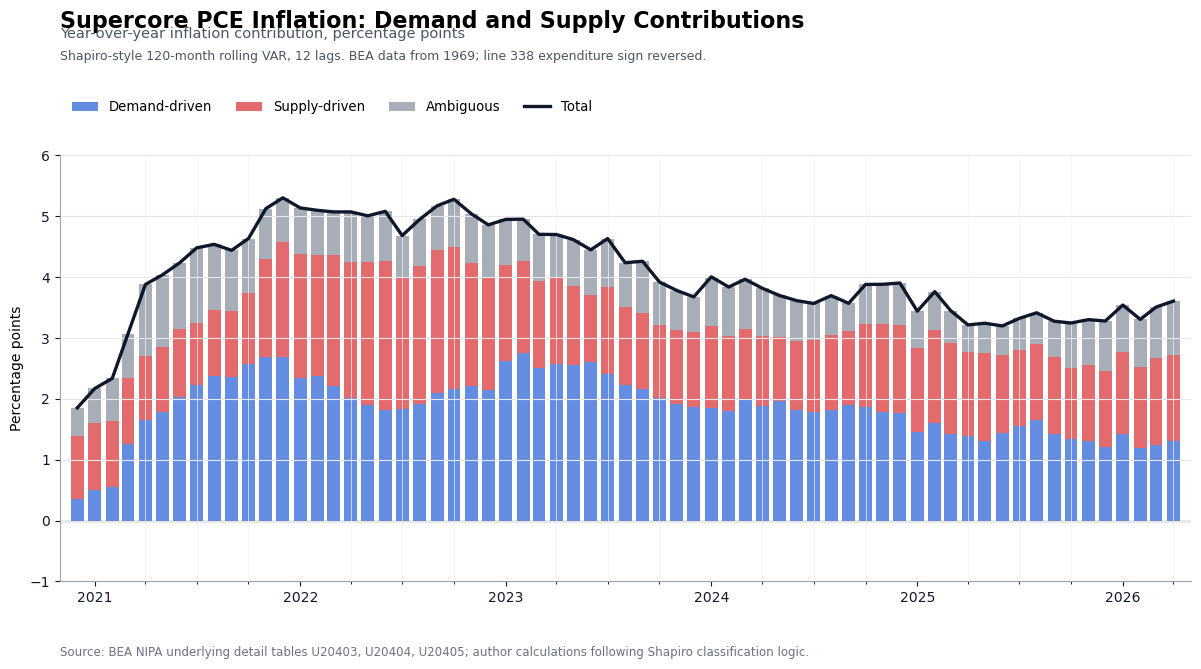

C:\Users\abour\OneDrive\Inflation Dynamics\Wage Growth Paper\Demand_Supply Decomp\output\shapiro_supercore_decomp\figures\supercore_shapiro_yoy_decomposition.png


In [20]:
def write_svg_decomposition_chart(df, path):
    plot_df = df[["dem_contr_y", "sup_contr_y", "amb_contr_y", "stacked_total_y"]].dropna().copy()
    width, height = 1200, 720
    margin = {"left": 78, "right": 34, "top": 128, "bottom": 96}
    inner_w = width - margin["left"] - margin["right"]
    inner_h = height - margin["top"] - margin["bottom"]
    dates = plot_df.index
    x0, x1 = dates.min().value, dates.max().value
    components = ["dem_contr_y", "sup_contr_y", "amb_contr_y"]
    pos_stack = plot_df[components].clip(lower=0).sum(axis=1)
    neg_stack = plot_df[components].clip(upper=0).sum(axis=1)
    y_min = min(0.0, float(neg_stack.min()), float(plot_df["stacked_total_y"].min()))
    y_max = max(1.0, float(pos_stack.max()), float(plot_df["stacked_total_y"].max()))
    pad = 0.10 * (y_max - y_min)
    y_min = math.floor((y_min - pad) * 2) / 2
    y_max = math.ceil((y_max + pad) * 2) / 2

    def sx(dt):
        return margin["left"] + (dt.value - x0) / (x1 - x0) * inner_w if x1 != x0 else margin["left"]

    def sy(v):
        return margin["top"] + (y_max - v) / (y_max - y_min) * inner_h

    colors = {
        "dem_contr_y": "#4f7ddf",
        "sup_contr_y": "#e15759",
        "amb_contr_y": "#9ca3af",
        "stacked_total_y": "#0f172a",
    }
    labels = {
        "dem_contr_y": "Demand-driven",
        "sup_contr_y": "Supply-driven",
        "amb_contr_y": "Ambiguous",
        "stacked_total_y": "Total",
    }

    n = len(plot_df)
    bar_w = max(3.0, min(13.0, inner_w / max(n, 1) * 0.72))
    y_tick_step = 1 if (y_max - y_min) <= 7 else 2
    y_ticks = np.arange(math.ceil(y_min), math.floor(y_max) + 0.1, y_tick_step)
    year_ticks = pd.date_range(dates.min(), dates.max(), freq="YS")
    if len(year_ticks) == 0 or year_ticks[0] != dates.min():
        year_ticks = year_ticks.insert(0, dates.min())

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial, Helvetica, sans-serif; fill:#111827;} .small{font-size:12px; fill:#4b5563;} .axis{font-size:12px; fill:#374151;} .title{font-size:23px; font-weight:700;} .subtitle{font-size:14px; fill:#4b5563;} .note{font-size:11px; fill:#6b7280;}</style>',
        '<text x="78" y="36" class="title">Supercore PCE Inflation: Demand and Supply Contributions</text>',
        '<text x="78" y="61" class="subtitle">Year-over-year inflation contribution, percentage points</text>',
        f'<text x="78" y="82" class="note">Shapiro-style 120-month rolling VAR, 12 lags. BEA data from {START_YEAR}; line 338 expenditure sign reversed.</text>',
    ]
    legend_x = margin["left"]
    legend_y = 108
    for col in ["dem_contr_y", "sup_contr_y", "amb_contr_y"]:
        parts.append(f'<rect x="{legend_x}" y="{legend_y - 10}" width="16" height="16" fill="{colors[col]}" opacity="0.88"/>')
        parts.append(f'<text x="{legend_x + 24}" y="{legend_y + 3}" class="small">{labels[col]}</text>')
        legend_x += 160
    parts.append(f'<line x1="{legend_x}" x2="{legend_x + 28}" y1="{legend_y - 2}" y2="{legend_y - 2}" stroke="{colors["stacked_total_y"]}" stroke-width="3"/>')
    parts.append(f'<text x="{legend_x + 36}" y="{legend_y + 3}" class="small">{labels["stacked_total_y"]}</text>')

    for tick in y_ticks:
        y = sy(tick)
        parts.append(f'<line x1="{margin["left"]}" x2="{width - margin["right"]}" y1="{y:.1f}" y2="{y:.1f}" stroke="#e5e7eb" stroke-width="1"/>')
        parts.append(f'<text x="{margin["left"] - 10}" y="{y + 4:.1f}" text-anchor="end" class="axis">{tick:.0f}</text>')
    zero_y = sy(0)
    parts.append(f'<line x1="{margin["left"]}" x2="{width - margin["right"]}" y1="{zero_y:.1f}" y2="{zero_y:.1f}" stroke="#6b7280" stroke-width="1"/>')

    for idx, data_row in plot_df.iterrows():
        x = sx(idx) - bar_w / 2
        pos_base = 0.0
        neg_base = 0.0
        for col in components:
            val = float(data_row[col])
            if not np.isfinite(val) or val == 0:
                continue
            if val >= 0:
                y_top = sy(pos_base + val)
                y_bottom = sy(pos_base)
                pos_base += val
            else:
                y_top = sy(neg_base)
                y_bottom = sy(neg_base + val)
                neg_base += val
            rect_y = min(y_top, y_bottom)
            rect_h = abs(y_bottom - y_top)
            parts.append(f'<rect x="{x:.1f}" y="{rect_y:.1f}" width="{bar_w:.1f}" height="{rect_h:.1f}" fill="{colors[col]}" opacity="0.88"/>')

    pts = " ".join(f"{sx(idx):.1f},{sy(val):.1f}" for idx, val in plot_df["stacked_total_y"].items() if np.isfinite(val))
    parts.append(f'<polyline points="{pts}" fill="none" stroke="{colors["stacked_total_y"]}" stroke-width="3" stroke-linejoin="round" stroke-linecap="round"/>')

    for tick in year_ticks:
        if tick < dates.min() or tick > dates.max():
            continue
        x = sx(tick)
        parts.append(f'<line x1="{x:.1f}" x2="{x:.1f}" y1="{height - margin["bottom"]}" y2="{height - margin["bottom"] + 5}" stroke="#9ca3af"/>')
        parts.append(f'<text x="{x:.1f}" y="{height - margin["bottom"] + 24}" text-anchor="middle" class="axis">{tick.year}</text>')
    parts.append(f'<text x="{margin["left"]}" y="{height - 28}" class="note">Source: BEA NIPA underlying detail tables U20403, U20404, U20405; author calculations following Shapiro classification logic.</text>')
    parts.append("</svg>")
    Path(path).write_text("\n".join(parts), encoding="utf-8")
    return Path(path)

def plot_decomposition(df):
    plot_df = df[["dem_contr_y", "sup_contr_y", "amb_contr_y", "stacked_total_y"]].dropna().copy()
    png_path = FIG / "supercore_shapiro_yoy_decomposition.png"
    svg_path = FIG / "supercore_shapiro_yoy_decomposition.svg"
    try:
        import matplotlib.pyplot as plt
        import matplotlib.dates as mdates
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch

        fig, ax = plt.subplots(figsize=(12.5, 7.1))
        components = [
            ("dem_contr_y", "Demand-driven", "#4f7ddf"),
            ("sup_contr_y", "Supply-driven", "#e15759"),
            ("amb_contr_y", "Ambiguous", "#9ca3af"),
        ]
        pos_bottom = np.zeros(len(plot_df))
        neg_bottom = np.zeros(len(plot_df))
        x = plot_df.index
        for col, label, color in components:
            vals = plot_df[col].to_numpy(dtype=float)
            bottom = np.where(vals >= 0, pos_bottom, neg_bottom)
            ax.bar(x, vals, bottom=bottom, width=23, label=label, color=color, alpha=0.88, linewidth=0)
            pos_bottom += np.where(vals >= 0, vals, 0.0)
            neg_bottom += np.where(vals < 0, vals, 0.0)

        ax.plot(plot_df.index, plot_df["stacked_total_y"], color="#0f172a", lw=2.4, label="Total", zorder=5)
        ax.axhline(0, color="#4b5563", lw=0.9, zorder=1)
        ax.set_ylabel("Percentage points", fontsize=10)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
        ax.grid(axis="y", color="#e5e7eb", linewidth=0.8)
        ax.grid(axis="x", which="minor", color="#f3f4f6", linewidth=0.5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines["left"].set_color("#9ca3af")
        ax.spines["bottom"].set_color("#9ca3af")
        ax.tick_params(axis="both", labelsize=10, colors="#111827")
        ax.margins(x=0.01)

        y_min = min(0.0, float(np.nanmin(neg_bottom)), float(plot_df["stacked_total_y"].min()))
        y_max = max(1.0, float(np.nanmax(pos_bottom)), float(plot_df["stacked_total_y"].max()))
        pad = 0.10 * (y_max - y_min)
        ax.set_ylim(math.floor((y_min - pad) * 2) / 2, math.ceil((y_max + pad) * 2) / 2)

        fig.subplots_adjust(left=0.08, right=0.985, top=0.76, bottom=0.16)
        fig.suptitle(
            "Supercore PCE Inflation: Demand and Supply Contributions",
            x=0.08,
            y=0.965,
            ha="left",
            fontsize=16,
            fontweight="bold",
        )
        fig.text(
            0.08,
            0.925,
            "Year-over-year inflation contribution, percentage points",
            fontsize=10.5,
            color="#4b5563",
        )
        fig.text(
            0.08,
            0.895,
            f"Shapiro-style 120-month rolling VAR, 12 lags. BEA data from {START_YEAR}; line 338 expenditure sign reversed.",
            fontsize=9,
            color="#4b5563",
        )
        handles = [
            Patch(facecolor="#4f7ddf", edgecolor="none", alpha=0.88, label="Demand-driven"),
            Patch(facecolor="#e15759", edgecolor="none", alpha=0.88, label="Supply-driven"),
            Patch(facecolor="#9ca3af", edgecolor="none", alpha=0.88, label="Ambiguous"),
            Line2D([0], [0], color="#0f172a", lw=2.4, label="Total"),
        ]
        fig.legend(
            handles=handles,
            ncol=4,
            loc="upper left",
            bbox_to_anchor=(0.08, 0.855),
            frameon=False,
            fontsize=9.5,
            handlelength=2.0,
            columnspacing=1.8,
        )
        fig.text(
            0.08,
            0.055,
            "Source: BEA NIPA underlying detail tables U20403, U20404, U20405; author calculations following Shapiro classification logic.",
            fontsize=8.5,
            color="#6b7280",
        )
        fig.savefig(svg_path, bbox_inches="tight")
        fig.savefig(png_path, dpi=180, bbox_inches="tight")
        plt.show()
        return png_path
    except Exception as exc:
        print(f"Matplotlib chart failed or is unavailable ({exc}); writing SVG fallback.")
        return write_svg_decomposition_chart(df, svg_path)

chart_path = plot_decomposition(decomp)
print(chart_path)


## 8. Method Notes and Next Steps


In [ ]:
summary = {
    "line_count": len(SUPERCORE_LINES),
    "data_start": str(common_dates.min().date()),
    "data_end": str(common_dates.max().date()),
    "classified_monthly_start": str(monthly.index.min().date()),
    "classified_monthly_end": str(monthly.index.max().date()),
    "first_yoy_decomposition": str(decomp["stacked_total_y"].dropna().index.min().date()),
    "rolling_window_months": ROLLING_WINDOW,
    "var_lags": VAR_LAGS,
    "threshold1_ambiguous": THRESH1,
    "negative_spend_lines": sorted(NEGATIVE_SPEND_LINES.intersection(SUPERCORE_LINES)),
}
pd.Series(summary)


### Notes

- This is a line-item contribution decomposition, not an official BEA
  chain-type aggregate for supercore. The total is built from lagged nominal
  expenditure shares and monthly line-item price-index changes, matching the
  contribution logic in Shapiro's Stata code.
- With `THRESH1 = 0.0`, nearly every item-month with finite residuals is forced
  into demand or supply. Raising `THRESH1` to `0.10` recreates Shapiro's
  "ambiguous" robustness threshold.
- Line 338 is treated as a subtraction line in expenditure weights. Quantity
  and price indexes are not sign-flipped, consistent with the Stata pattern of
  flipping spending only.
- To extend the sample, set `START_YEAR` to an earlier year and rerun. BEA's
  monthly underlying-detail tables currently provide data back to 1959 for
  these tables, but some highly granular line availability can vary.
